In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
from linearmodels.panel import PanelOLS
from scipy.stats import skew, kurtosis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scienceplots
plt.style.use('seaborn-v0_8-deep')

import os 
path = os.path.abspath(os.path.join(os.getcwd(),'final_clean'))
path2 = os.path.abspath(os.path.join(os.getcwd(),'final_LaTeX', 'pt_test'))

pd.set_option('display.max_columns', None)

In [2]:
d1 = pd.read_csv(f"{path}/patents_dataset.csv")
d1 = d1.query("country in ['CHE', 'IRL']").reset_index(drop=True)
d1['year'].max()

2018

In [3]:
d1['treated'] = d1['country'].apply(lambda x: 1 if x == 'IRL' else 0)


d1['pre'] = d1['year'].apply(lambda x: 1 if x < 2015 else 0)
d1['post'] = d1['year'].apply(lambda x: 1 if x >= 2015 else 0)

d1 = d1[d1['year'] >= 1996]
# Variable temps (t)
d1['time'] = d1['year']


d1['treated_pre_time'] = d1['treated'] * d1['pre'] * d1['time']
d1['treated_post_time'] = d1['treated'] * d1['post'] * d1['time']

In [4]:
formula = 'brevets ~ treated * post + treated_pre_time + treated_post_time + C(year) + C(country)'
model = smf.ols(formula, data=d1).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                brevets   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     31.93
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           7.23e-11
Time:                        07:37:50   Log-Likelihood:                 33.161
No. Observations:                  46   AIC:                            -12.32
Df Residuals:                      19   BIC:                             37.05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.3979      0.14

In [ ]:
# print(model.summary().as_latex()) # Best way = copy paste in a .tex file

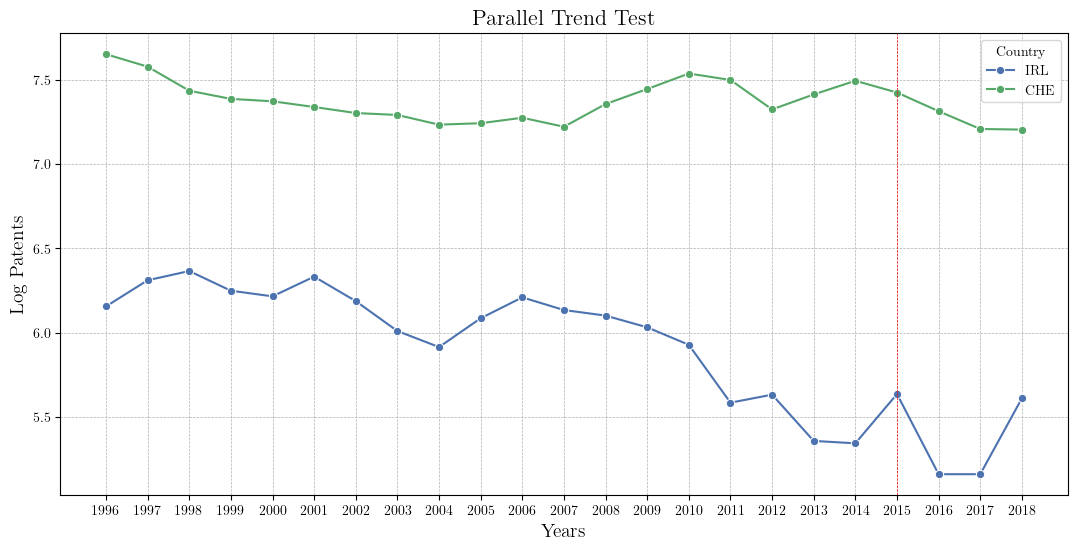

In [6]:

# Plot scientifique avec LaTeX
plt.figure(figsize=(13, 6))
sns.lineplot(data=d1, x='year', y='brevets', hue='country', marker='o')
plt.axvline(x=2015, color='red', linestyle='--', linewidth=0.5)
plt.title(r'Parallel Trend Test', fontsize=16)
plt.xlabel(r'Years', fontsize=14)
plt.ylabel(r'Log Patents', fontsize=14)
plt.legend(title='Country')
plt.grid(True, linestyle='--', linewidth=0.5)
# plt.text(2016, max(d1['brevets']), '2016', color='red', ha='left', va='bottom')
plt.xticks(ticks=np.arange(d1['year'].min(), d1['year'].max() + 1, 1))
# Utiliser LaTeX pour le rendu des textes
plt.rc('font', family='serif', serif='Latin Modern Roman')
plt.rc('text', usetex=True)

plt.show()
res = model.summary()

In [7]:
# # Extract the HTML table from the model summary
# html_table = model.summary().tables[1].as_html()
# # Read the HTML table into a DataFrame
# res_df = pd.read_html(html_table, header=0, index_col=0)[0]
# res_df = res_df.iloc[22:23]
# # res_df.to_latex(path + '/brevets_test.tex', index=False)

In [8]:
df = pd.read_csv(f"{path}/depreciation_dataset.csv")

df = df.query("country in ['FIN', 'IRL']").reset_index(drop=True)
df['country'].unique()

array(['FIN', 'IRL'], dtype=object)

In [9]:
df['treated'] = df['country'].apply(lambda x: 1 if x == 'IRL' else 0)

df['pre'] = df['year'].apply(lambda x: 1 if x < 2015 else 0)
df['post'] = df['year'].apply(lambda x: 1 if x >= 2015 else 0)

df = df[df['year'] >= 1996]

df['time'] = df['year']


df['treated_pre_time'] = df['treated'] * df['pre'] * df['time']
df['treated_post_time'] = df['treated'] * df['post'] * df['time']


In [10]:
formula_ = 'depreciation ~ treated * post + treated_pre_time + treated_post_time + C(year) + C(country)'
model2 = smf.ols(formula_, data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           depreciation   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     47.25
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           2.02e-12
Time:                        07:40:05   Log-Likelihood:                 125.38
No. Observations:                  46   AIC:                            -196.8
Df Residuals:                      19   BIC:                            -147.4
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0447      0.01

In [11]:
# print(model2.summary().as_latex()) # Best way = copy paste in a .tex file

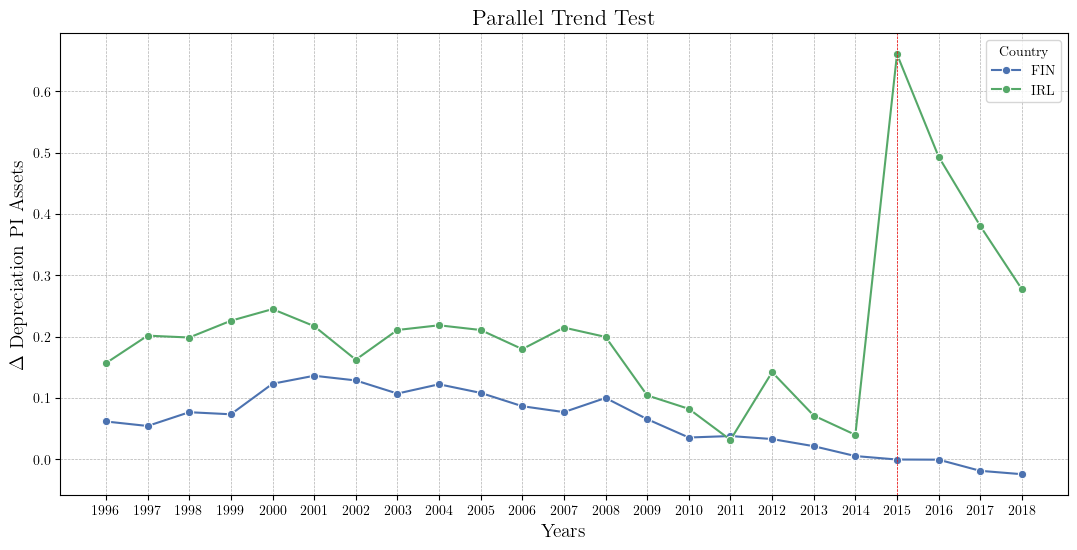

In [11]:
plt.figure(figsize=(13, 6))
sns.lineplot(data=df, x='year', y='depreciation', hue='country', marker='o')
plt.axvline(x=2015, color='red', linestyle='--', linewidth=0.5)
plt.title(r'Parallel Trend Test', fontsize=16)
plt.xlabel(r'Years', fontsize=14)
plt.ylabel(r'$\Delta$ Depreciation PI Assets', fontsize=14)
plt.legend(title='Country')
plt.grid(True, linestyle='--', linewidth=0.5)
# plt.text(2016, max(df['brevets']), '2016', color='red', ha='left', va='bottom')
plt.xticks(ticks=np.arange(df['year'].min(), df['year'].max() + 1, 1))
# Utiliser LaTeX pour le rendu des textes
plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif='Latin Modern Roman')

plt.show()
res2 = model2.summary()

In [28]:
bbb = model.summary() # Change for model 1 to get for the patents

bbb = bbb.tables[0].as_html()
bbb = pd.read_html(bbb, header=0, index_col=0)[0]

bbb.columns
bbb.set_index('R-squared:', inplace=True)
bbb = bbb.iloc[1:3, 1:2].T
bbb

/var/folders/k9/pvn_th0d1nq47_956zvk1l4c0000gn/T/ipykernel_7245/982646507.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  bbb = pd.read_html(bbb, header=0, index_col=0)[0]


R-squared:,F-statistic:,Prob (F-statistic):
0.978,31.93,7.230000e-11


In [ ]:
# Extract the HTML table from the model summary
# tab_dep = model2.summary().tables[1].as_html()
# # Read the HTML table into a DataFrame
# res_dep = pd.read_html(tab_dep, header=0, index_col=0)[0]
# res_dep = res_dep.iloc[22:23]
# res_dep
aaa = model2.summary() # Change for model 1 to get for the patents

aaa = aaa.tables[0].as_html()
aaa = pd.read_html(aaa, header=0, index_col=0)[0]

aaa.columns
aaa.set_index('R-squared:', inplace=True)
aaa = aaa.iloc[1:3, 1:2].T

/var/folders/k9/pvn_th0d1nq47_956zvk1l4c0000gn/T/ipykernel_7245/2256223215.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  aaa = pd.read_html(aaa, header=0, index_col=0)[0]


In [19]:
aaa

R-squared:,F-statistic:,Prob (F-statistic):
0.985,47.25,2.020000e-12


In [ ]:
# bbb.to_latex(f"{path2}/patents_test.tex", index=False)
# aaa.to_latex(f"{path2}/depreciation_test.tex", index=False)